In [1]:
"""
run_and_plot_baseline.py
========================
Sets up the NPxZxf model using CARIACO steady-state forcings, runs the simulation,
and plots the final steady-state output against observational data.
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xso

# Import your model, base variables, and size arrays
from npxzxf_models import model, BASE_INPUT_VARS, phyto_esd, zoo_esd

# Import your new data processor
from cariaco_data_processor import calculate_steady_state_forcings, process_observational_data

# =============================================================================
# 1. HELPER FUNCTIONS FOR AGGREGATION
# =============================================================================

def get_log_bin_edges(centers):
    q = centers[1] / centers[0]
    half_step = np.sqrt(q)
    edges = np.zeros(len(centers) + 1)
    edges[0] = centers[0] / half_step
    edges[1:] = centers * half_step
    return edges

def get_fraction_in_range(lower, upper, target_min, target_max):
    overlap_min = max(lower, target_min)
    overlap_max = min(upper, target_max)
    if overlap_min >= overlap_max:
        return 0.0
    return (np.log10(overlap_max) - np.log10(overlap_min)) / (np.log10(upper) - np.log10(lower))

def aggregate_model_state(ss_phyto, ss_zoo, ss_nut, p_esd, z_esd):
    """Groups the model output using fractional overlaps."""
    p_edges = get_log_bin_edges(p_esd)
    micro_n, nano_n, pico_n = 0.0, 0.0, 0.0
    
    for i in range(len(p_esd)):
        lower, upper, biomass = p_edges[i], p_edges[i+1], ss_phyto[i]
        pico_n += biomass * get_fraction_in_range(lower, upper, 1e-9, 2.0)
        nano_n += biomass * get_fraction_in_range(lower, upper, 2.0, 20.0)
        micro_n += biomass * get_fraction_in_range(lower, upper, 20.0, 1e9)
        
    z_edges = get_log_bin_edges(z_esd)
    zoo_gt_200, zoo_gt_500 = 0.0, 0.0
    
    for i in range(len(z_esd)):
        lower, upper, biomass = z_edges[i], z_edges[i+1], ss_zoo[i]
        zoo_gt_200 += biomass * get_fraction_in_range(lower, upper, 200.0, 1e9)
        zoo_gt_500 += biomass * get_fraction_in_range(lower, upper, 500.0, 1e9)
        
    return [micro_n, nano_n, pico_n], [zoo_gt_200, zoo_gt_500], [float(ss_nut)]

# =============================================================================
# 2. GET FORCINGS AND OBSERVATIONS
# =============================================================================

print("Loading data and forcings...")
forcings = calculate_steady_state_forcings()
verif_means, (phyto_data, zoo_data, nut_data) = process_observational_data()

# =============================================================================
# 3. SETUP AND RUN MODEL
# =============================================================================

print("Setting up model...")
# Copy base vars and inject the new steady-state nutrient flux
cariaco_inputs = BASE_INPUT_VARS.copy()

# Note: Adjust the key ('Inflow' / 'rate' / 'forcing') based on exactly how 
# you named the parameters in your swapped LinearForcingInput component.
cariaco_inputs.update({
    'Inflow': {**BASE_INPUT_VARS['Inflow'], 'forcing': forcings['linear_N_input_flux']},
})

# Setup the model to run for enough days to reach steady state (e.g., 2000)
baseline_setup = xso.setup(
    solver='solve_ivp',
    model=model,
    time=np.arange(0, 2000),
    input_vars=cariaco_inputs,
)

print("Running simulation...")
with model:
    out = baseline_setup.xsimlab.run()

# =============================================================================
# 4. PROCESS OUTPUT
# =============================================================================

# Extract final steady-state values
ss_phyto_spectrum = out.Phytoplankton__biomass.isel(time=-1).values
ss_zoo_spectrum = out.Zooplankton__biomass.isel(time=-1).values
ss_nutrient = out.Nutrient__value.isel(time=-1).values

# Aggregate into observational bins
model_p, model_z, model_n = aggregate_model_state(
    ss_phyto_spectrum, ss_zoo_spectrum, ss_nutrient, phyto_esd, zoo_esd
)

# =============================================================================
# 5. PLOT RESULTS
# =============================================================================

print("Generating plots...")
fig, axes = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={'width_ratios': [3, 2, 1]})

box_palette = "lightgray"
model_marker = dict(marker='*', color='red', s=200, edgecolor='black', zorder=5, label='Model (Steady State)')

# 1. Phytoplankton
sns.boxplot(data=phyto_data, ax=axes[0], color=box_palette, showmeans=True, showfliers=False)
axes[0].scatter(range(len(model_p)), model_p, **model_marker)
axes[0].set_title('Phytoplankton', fontsize=14)
axes[0].set_ylabel('Biomass (mmol N m⁻³)', fontsize=12)
axes[0].legend()

# 2. Zooplankton
sns.boxplot(data=zoo_data, ax=axes[1], color=box_palette, showmeans=True, showfliers=False)
axes[1].scatter(range(len(model_z)), model_z, **model_marker)
axes[1].set_title('Zooplankton', fontsize=14)

# 3. Nutrients
sns.boxplot(data=nut_data, ax=axes[2], color=box_palette, showmeans=True, showfliers=False)
axes[2].scatter([0], model_n, **model_marker)
axes[2].set_title('Nutrients', fontsize=14)

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('CARIACO Ecosystem State: Observations vs. Baseline Model', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Done!")

Loading data and forcings...
Setting up model...
Running simulation...


KeyError: 0.059407549714213546

# CARIACO NPxZxf — Parameter Scan Workbench

Systematic exploration of model parameter space against CARIACO time-series constraints.  
Uses `xso.parscans` for parallelised 1-D and 2-D sweeps.

**Current baseline diagnosis:**
| Issue | Symptom |
|---|---|
| Pico-phyto blooms unchecked | Model: 1.25 vs Obs: 0.18 mmol N m⁻³ |
| Micro-phyto & zoo collapse | Model ≈ 0 vs Obs ≈ 0.05–0.16 |
| Nutrients depleted | Model: 0.03 vs Obs: 2.0 |

→ Likely culprits: grazing half-saturation (`KsZ`), zoo mortality (`m_Z`), nutrient supply, fish pressure.

---
## 0 — Imports & Setup

In [9]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from xso.parscans import run_xso_parscan, run_xso_stabilityscan
from npxzxf_models import (
    model, model_setup_ivp, model_setup_stability,
    phyto_esd, zoo_esd, n_classes,
    run_model_test, run_model_test_stability,
)

# Plotting defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.figsize': (12, 5),
})

print(f"Phyto ESD classes: {np.round(phyto_esd, 2)} µm")
print(f"Zoo   ESD classes: {np.round(zoo_esd, 1)} µm")
print(f"n_classes = {n_classes}")

# ── Observational targets (mmol N m⁻³) ──────────────────────────────
OBS_TARGETS = {
    'micro_phyto': {'mean': 0.15627, 'median': 0.09544},
    'nano_phyto':  {'mean': 0.12162, 'median': 0.11883},
    'pico_phyto':  {'mean': 0.17506, 'median': 0.17513},
    'zoo_gt200':   {'mean': 0.05934, 'median': 0.05304},
    'zoo_gt500':   {'mean': 0.03280, 'median': 0.02617},
    'NO3':         {'mean': 2.01581, 'median': 1.63575},
}

# ── CARIACO physical forcings (constant across scans) ────────────────
CARIACO_BASE = {
    'N0__value':          5.5564,   # Sub-euphotic NO3 (50–70 m mean)
    'Inflow__rate':       0.016786, # Dilution rate  (d⁻¹)
    'Nutrient__value_init': 2.0158, # Euphotic NO3 initial condition
    'FishForcing__value': 0.1,      # Placeholder fish biomass
}

print("Observational targets loaded.")
for k, v in OBS_TARGETS.items():
    print(f"  {k:>15s}:  mean={v['mean']:.4f}  median={v['median']:.4f}")

Phyto ESD classes: [  0.5    1.36   3.68  10.    27.14  73.68 200.  ] µm
Zoo   ESD classes: [   5.    13.6   36.8  100.   271.4  736.8 2000. ] µm
n_classes = 7
Observational targets loaded.
      micro_phyto:  mean=0.1563  median=0.0954
       nano_phyto:  mean=0.1216  median=0.1188
       pico_phyto:  mean=0.1751  median=0.1751
        zoo_gt200:  mean=0.0593  median=0.0530
        zoo_gt500:  mean=0.0328  median=0.0262
              NO3:  mean=2.0158  median=1.6358


---
## 1 — Observational Targets

Pre-computed from the CARIACO time-series (see `model_vs_data_plot.py`).

In [10]:
# ── Observational targets (mmol N m⁻³) ──────────────────────────────
OBS_TARGETS = {
    'micro_phyto': {'mean': 0.15627, 'median': 0.09544},
    'nano_phyto':  {'mean': 0.12162, 'median': 0.11883},
    'pico_phyto':  {'mean': 0.17506, 'median': 0.17513},
    'zoo_gt200':   {'mean': 0.05934, 'median': 0.05304},
    'zoo_gt500':   {'mean': 0.03280, 'median': 0.02617},
    'NO3':         {'mean': 2.01581, 'median': 1.63575},
}

# ── CARIACO physical forcings (constant across scans) ────────────────
CARIACO_BASE = {
    'N0__value':          5.5564,   # Sub-euphotic NO3 (50–70 m mean)
    'Inflow__rate':       0.016786, # Dilution rate  (d⁻¹)
    'Nutrient__value_init': 2.0158, # Euphotic NO3 initial condition
    'FishForcing__value': 0.1,      # Placeholder fish biomass
}

print("Observational targets loaded.")
for k, v in OBS_TARGETS.items():
    print(f"  {k:>15s}:  mean={v['mean']:.4f}  median={v['median']:.4f}")

Observational targets loaded.
      micro_phyto:  mean=0.1563  median=0.0954
       nano_phyto:  mean=0.1216  median=0.1188
       pico_phyto:  mean=0.1751  median=0.1751
        zoo_gt200:  mean=0.0593  median=0.0530
        zoo_gt500:  mean=0.0328  median=0.0262
              NO3:  mean=2.0158  median=1.6358


---
## 2 — Aggregation Helpers

Identical fractional-overlap logic used in the validation plot, packaged for reuse.

In [11]:
def get_log_bin_edges(centers):
    """N+1 edges for N log-spaced bin centers."""
    q = centers[1] / centers[0]
    half_step = np.sqrt(q)
    edges = np.zeros(len(centers) + 1)
    edges[0] = centers[0] / half_step
    edges[1:] = centers * half_step
    return edges


def frac_in_range(lo, hi, tmin, tmax):
    """Fractional overlap of [lo,hi] with [tmin,tmax] in log10 space."""
    omin, omax = max(lo, tmin), min(hi, tmax)
    if omin >= omax:
        return 0.0
    return (np.log10(omax) - np.log10(omin)) / (np.log10(hi) - np.log10(lo))


def aggregate_model(ss_phyto, ss_zoo, ss_nut, p_esd, z_esd):
    """
    Aggregate model size spectra → observational bins.
    Returns dict with same keys as OBS_TARGETS.
    """
    p_edges = get_log_bin_edges(p_esd)
    z_edges = get_log_bin_edges(z_esd)

    micro = nano = pico = 0.0
    for i in range(len(p_esd)):
        b = ss_phyto[i]
        lo, hi = p_edges[i], p_edges[i + 1]
        pico  += b * frac_in_range(lo, hi, 1e-9, 2.0)
        nano  += b * frac_in_range(lo, hi, 2.0, 20.0)
        micro += b * frac_in_range(lo, hi, 20.0, 1e9)

    z200 = z500 = 0.0
    for i in range(len(z_esd)):
        b = ss_zoo[i]
        lo, hi = z_edges[i], z_edges[i + 1]
        z200 += b * frac_in_range(lo, hi, 200.0, 1e9)
        z500 += b * frac_in_range(lo, hi, 500.0, 1e9)

    return {
        'micro_phyto': micro,
        'nano_phyto':  nano,
        'pico_phyto':  pico,
        'zoo_gt200':   z200,
        'zoo_gt500':   z500,
        'NO3':         float(ss_nut),
    }


def compute_cost(model_dict, obs_dict=OBS_TARGETS, metric='mean'):
    """Sum of squared log-ratios (robust to order-of-magnitude differences)."""
    cost = 0.0
    for key in obs_dict:
        obs_val = obs_dict[key][metric]
        mod_val = max(model_dict[key], 1e-12)  # floor to avoid log(0)
        cost += (np.log10(mod_val) - np.log10(max(obs_val, 1e-12))) ** 2
    return cost


print("Aggregation & cost functions ready.")

Aggregation & cost functions ready.


---
## 3 — Single-Parameter Scans (1-D)

Each scan varies one parameter while holding the CARIACO base fixed.  
We extract the aggregated model state at each scan point and compute cost.

### 3a — Define scan configurations

Add or modify entries here to scan any model parameter.

In [12]:
# ── 1-D scan definitions ─────────────────────────────────────────────
# Each entry: (xso_param_name, scan_values, label_for_plots)

SCANS_1D = {
    'KsZ': {
        'param': 'Grazing__KsZ',
        'values': np.linspace(0.1, 10.0, 40),
        'label': 'Grazing half-sat $K_Z$ (mmol N m$^{-3}$)',
    },
    'mZ': {
        'param': 'ZooMortality__rate',
        'values': np.linspace(0.001, 0.5, 40),
        'label': 'Zoo quadratic mortality $m_Z$ (d$^{-1}$)',
    },
    'N0': {
        'param': 'N0__value',
        'values': np.linspace(1.0, 15.0, 40),
        'label': 'Deep nutrient $N_0$ (mmol N m$^{-3}$)',
    },
    'dilution': {
        'param': 'Inflow__rate',
        'values': np.linspace(0.005, 0.1, 40),
        'label': 'Dilution rate $d$ (d$^{-1}$)',
    },
    'fish_biomass': {
        'param': 'FishForcing__value',
        'values': np.linspace(0.0, 1.0, 40),
        'label': 'Fish biomass $F$ (mmol N m$^{-3}$)',
    },
    'fish_rate': {
        'param': 'FishGrazing__rate',
        'values': np.linspace(0.001, 2.0, 40),
        'label': 'Fish grazing rate (d$^{-1}$)',
    },
}

print(f"Defined {len(SCANS_1D)} 1-D scans:")
for name, cfg in SCANS_1D.items():
    print(f"  {name:>15s}: {cfg['param']}  [{cfg['values'][0]:.3f} → {cfg['values'][-1]:.3f}], n={len(cfg['values'])}")

Defined 6 1-D scans:
              KsZ: Grazing__KsZ  [0.100 → 10.000], n=40
               mZ: ZooMortality__rate  [0.001 → 0.500], n=40
               N0: N0__value  [1.000 → 15.000], n=40
         dilution: Inflow__rate  [0.005 → 0.100], n=40
     fish_biomass: FishForcing__value  [0.000 → 1.000], n=40
        fish_rate: FishGrazing__rate  [0.001 → 2.000], n=40


### 3b — Run a 1-D scan

Pick a scan by name, run it, then extract & aggregate results.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  SELECT WHICH 1-D SCAN TO RUN
# ══════════════════════════════════════════════════════════════════════
SCAN_NAME = 'KsZ'   # ← change this to run a different scan
N_PROCS   = 20      # ← number of parallel processes
# ══════════════════════════════════════════════════════════════════════

cfg = SCANS_1D[SCAN_NAME]
print(f"Running 1-D scan: {SCAN_NAME} ({cfg['param']})")
print(f"  Range: {cfg['values'][0]:.4f} → {cfg['values'][-1]:.4f}, n={len(cfg['values'])}")

scan_results = run_xso_parscan(
    model_file_name='npxzxf_models',
    model_name='model',
    model_setup_name='model_setup_ivp_cariaco',
    param_name=cfg['param'],
    param_values=cfg['values'],
    processes=N_PROCS,
)

if scan_results is None:
    raise RuntimeError(f"1-D scan '{SCAN_NAME}' failed.")

print("Scan complete.")
print(scan_results)

### 3c — Aggregate & visualise the 1-D scan

In [6]:
# ── Extract final time-step across the scan ──────────────────────────
P_final = scan_results['Phytoplankton__biomass'].isel(time=-1)  # (param, phyto)
Z_final = scan_results['Zooplankton__biomass'].isel(time=-1)    # (param, zoo)
N_final = scan_results['Nutrient__value'].isel(time=-1)         # (param,)

param_vals = cfg['values']
n_scan = len(param_vals)

# ── Aggregate each scan point ────────────────────────────────────────
agg_keys = list(OBS_TARGETS.keys())
agg_results = {k: np.zeros(n_scan) for k in agg_keys}
cost_vals   = np.zeros(n_scan)

for idx in range(n_scan):
    agg = aggregate_model(
        P_final.isel({cfg['param']: idx}).values if cfg['param'] in P_final.dims
            else P_final[idx].values,
        Z_final.isel({cfg['param']: idx}).values if cfg['param'] in Z_final.dims
            else Z_final[idx].values,
        float(N_final[idx].values) if hasattr(N_final[idx], 'values')
            else float(N_final[idx]),
        phyto_esd, zoo_esd,
    )
    for k in agg_keys:
        agg_results[k][idx] = agg[k]
    cost_vals[idx] = compute_cost(agg)

print(f"Min cost = {cost_vals.min():.4f} at {cfg['param']} = {param_vals[np.argmin(cost_vals)]:.4f}")

Min cost = 3.4997 at Grazing__KsZ = 1.3692


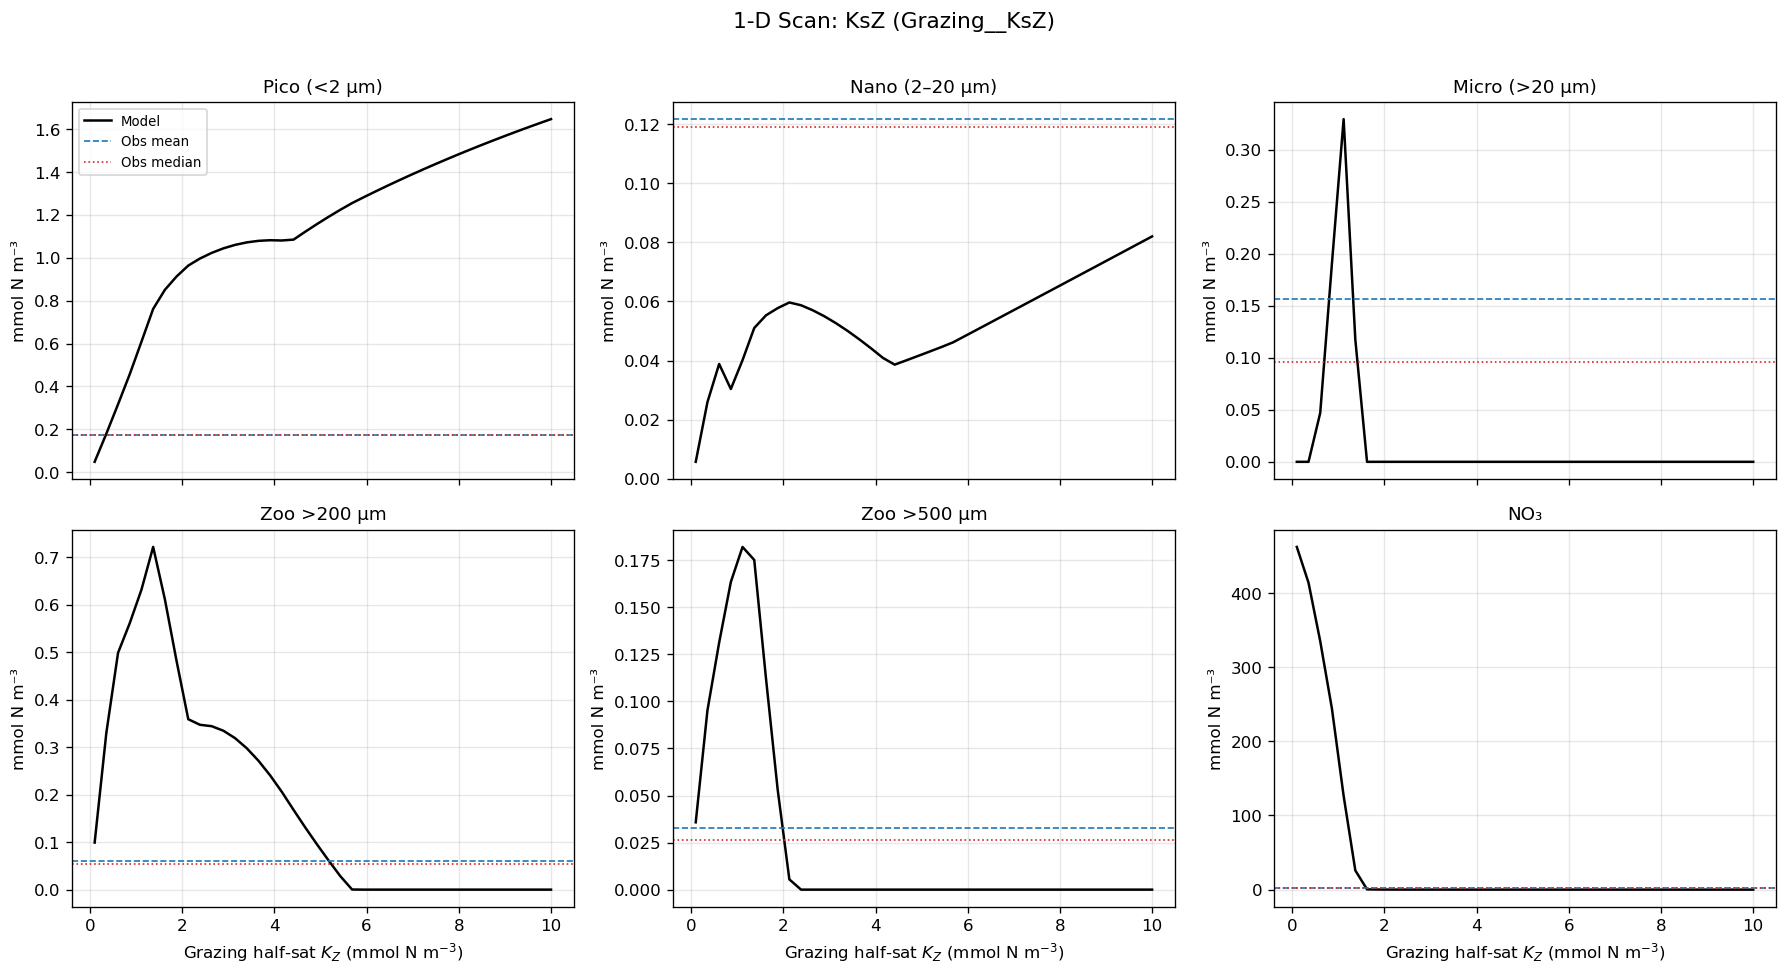

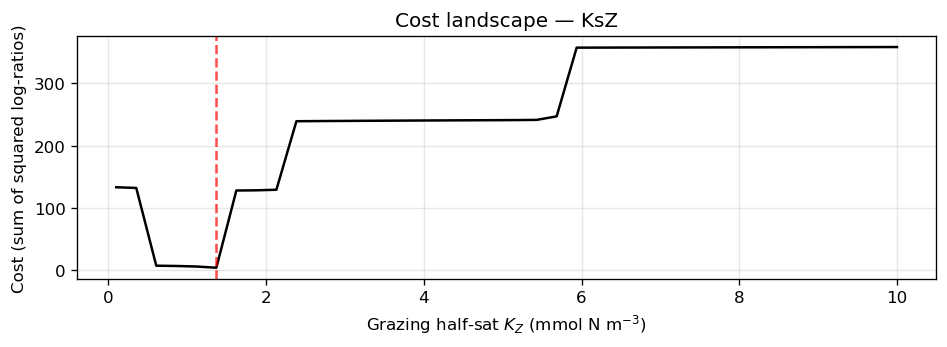

In [7]:
# ── Plot: aggregated state variables + cost ──────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
axes = axes.ravel()

plot_order = ['pico_phyto', 'nano_phyto', 'micro_phyto',
              'zoo_gt200', 'zoo_gt500', 'NO3']
plot_labels = ['Pico (<2 µm)', 'Nano (2–20 µm)', 'Micro (>20 µm)',
               'Zoo >200 µm', 'Zoo >500 µm', 'NO₃']

for ax, key, label in zip(axes, plot_order, plot_labels):
    ax.plot(param_vals, agg_results[key], 'k-', lw=1.5, label='Model')
    ax.axhline(OBS_TARGETS[key]['mean'],   color='C0', ls='--', lw=1, label='Obs mean')
    ax.axhline(OBS_TARGETS[key]['median'], color='C3', ls=':',  lw=1, label='Obs median')
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('mmol N m⁻³')
    if ax == axes[0]:
        ax.legend(fontsize=8)

for ax in axes[3:]:
    ax.set_xlabel(cfg['label'])

fig.suptitle(f"1-D Scan: {SCAN_NAME} ({cfg['param']})", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Cost curve ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(param_vals, cost_vals, 'k-', lw=1.5)
ax.axvline(param_vals[np.argmin(cost_vals)], color='red', ls='--', alpha=0.7)
ax.set_xlabel(cfg['label'])
ax.set_ylabel('Cost (sum of squared log-ratios)')
ax.set_title(f'Cost landscape — {SCAN_NAME}')
plt.tight_layout()
plt.show()

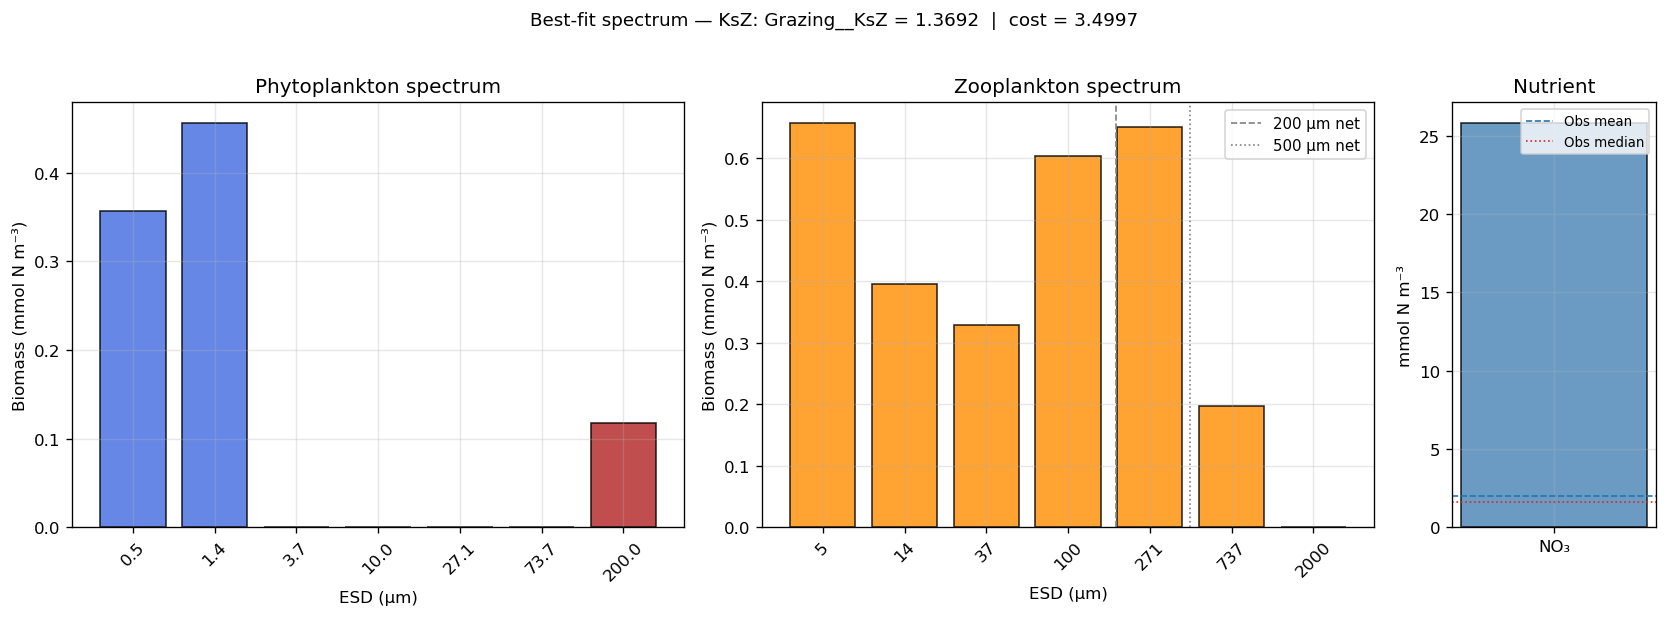

In [8]:
# ── Best-fit size spectrum from 1-D scan ─────────────────────────────
best_idx_1d = np.argmin(cost_vals)
best_val    = param_vals[best_idx_1d]

best_P = P_final[best_idx_1d].values
best_Z = Z_final[best_idx_1d].values
best_N = float(N_final[best_idx_1d].values)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5),
                                     gridspec_kw={'width_ratios': [3, 3, 1]})

# Phytoplankton spectrum
ax1.bar(range(len(phyto_esd)), best_P, color='seagreen', edgecolor='k', alpha=0.8)
ax1.set_xticks(range(len(phyto_esd)))
ax1.set_xticklabels([f'{e:.1f}' for e in phyto_esd], rotation=45)
ax1.set_xlabel('ESD (µm)')
ax1.set_ylabel('Biomass (mmol N m⁻³)')
ax1.set_title('Phytoplankton spectrum')

for i, e in enumerate(phyto_esd):
    if e < 2:
        ax1.patches[i].set_facecolor('royalblue')
    elif e < 20:
        ax1.patches[i].set_facecolor('gold')
    else:
        ax1.patches[i].set_facecolor('firebrick')

# Zooplankton spectrum
ax2.bar(range(len(zoo_esd)), best_Z, color='darkorange', edgecolor='k', alpha=0.8)
ax2.set_xticks(range(len(zoo_esd)))
ax2.set_xticklabels([f'{e:.0f}' for e in zoo_esd], rotation=45)
ax2.set_xlabel('ESD (µm)')
ax2.set_ylabel('Biomass (mmol N m⁻³)')
ax2.set_title('Zooplankton spectrum')

ax2.axvline(np.interp(200, zoo_esd, range(len(zoo_esd))), color='gray', ls='--', lw=1, label='200 µm net')
ax2.axvline(np.interp(500, zoo_esd, range(len(zoo_esd))), color='gray', ls=':',  lw=1, label='500 µm net')
ax2.legend(fontsize=9)

# Nutrient
ax3.bar(['NO₃'], [best_N], color='steelblue', edgecolor='k', alpha=0.8, width=0.5)
ax3.axhline(OBS_TARGETS['NO3']['mean'],   color='C0', ls='--', lw=1, label='Obs mean')
ax3.axhline(OBS_TARGETS['NO3']['median'], color='C3', ls=':',  lw=1, label='Obs median')
ax3.set_ylabel('mmol N m⁻³')
ax3.set_title('Nutrient')
ax3.legend(fontsize=8)

fig.suptitle(f'Best-fit spectrum — {SCAN_NAME}: {cfg["param"]} = {best_val:.4f}  |  cost = {cost_vals[best_idx_1d]:.4f}',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# ── Sweep all 1-D scans and rank the top fits ────────────────────────
from collections import defaultdict

all_fits = []  # list of (cost, scan_name, param_value, aggregated_dict)

for scan_name, cfg in SCANS_1D.items():
    print(f"Running: {scan_name} ({cfg['param']}) ...", end=" ", flush=True)
    
    res = run_xso_parscan(
        model_file_name='npxzxf_models',
        model_name='model',
        model_setup_name='model_setup_ivp_cariaco',
        param_name=cfg['param'],
        param_values=cfg['values'],
        processes=N_PROCS,
    )
    
    if res is None:
        print("FAILED")
        continue
    
    Pf = res['Phytoplankton__biomass'].isel(time=-1)
    Zf = res['Zooplankton__biomass'].isel(time=-1)
    Nf = res['Nutrient__value'].isel(time=-1)
    
    for idx, pval in enumerate(cfg['values']):
        agg = aggregate_model(
            Pf[idx].values, Zf[idx].values,
            float(Nf[idx].values), phyto_esd, zoo_esd,
        )
        c = compute_cost(agg)
        all_fits.append((c, scan_name, cfg['param'], pval, agg))
    
    print(f"done ({len(cfg['values'])} points)")

# ── Sort and report top 5 ────────────────────────────────────────────
all_fits.sort(key=lambda x: x[0])

print("\n" + "=" * 85)
print(" TOP 5 FITS ACROSS ALL 1-D SCANS")
print("=" * 85)
print(f"{'Rank':>4s}  {'Cost':>8s}  {'Scan':>15s}  {'Param':>25s}  {'Value':>10s}")
print("-" * 85)

for rank, (cost, sname, pname, pval, agg) in enumerate(all_fits[:5], 1):
    print(f"{rank:4d}  {cost:8.4f}  {sname:>15s}  {pname:>25s}  {pval:10.4f}")
    for k in OBS_TARGETS:
        obs = OBS_TARGETS[k]['mean']
        mod = agg[k]
        ratio = mod / obs if obs > 0 else np.inf
        print(f"{'':>66s}{k:>15s}  {mod:.5f}  ({ratio:.2f}x)")
    print()

print("=" * 85)

Running: KsZ (Grazing__KsZ) ... --- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup_ivp' from 'npxzxf_models'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'npxzxf_models' over 40 points using 20 workers...
1D Scan complete. Time taken: 172.31299 seconds.
done (40 points)
Running: mZ (ZooMortality__rate) ... --- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup_ivp' from 'npxzxf_models'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'npxzxf_models' over 40 points using 20 workers...
1D Scan complete. Time taken: 138.18639 seconds.
done (40 points)
Running: N0 (N0__value) ... --- Starting Parallel Scan (solve_ivp) ---
Validating model 'model' and setup 'model_setup_ivp' from 'npxzxf_models'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D paral

---
## 4 — Two-Parameter Scans (2-D)

Joint exploration of two parameters.  
Produces a cost heatmap to identify interaction effects and constrain the sweet spot.

### 4a — Define 2-D scan

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  SELECT 2-D SCAN PARAMETERS
# ══════════════════════════════════════════════════════════════════════
SCAN2D_X = 'Grazing__KsZ'
SCAN2D_Y = 'ZooMortality__rate'

x_vals = np.linspace(0.1, 8.0, 30)
y_vals = np.linspace(0.001, 0.3, 30)

N_PROCS_2D = 20
# ══════════════════════════════════════════════════════════════════════

print(f"2-D scan: {SCAN2D_X} × {SCAN2D_Y}")
print(f"  Grid: {len(x_vals)} × {len(y_vals)} = {len(x_vals)*len(y_vals)} runs")

### 4b — Run the 2-D scan

In [ ]:
scan2d_results = run_xso_parscan(
    model_file_name='npxzxf_models',
    model_name='model',
    model_setup_name='model_setup_ivp',
    param_name=SCAN2D_X,
    param_values=x_vals,
    param_name2=SCAN2D_Y,
    param_values2=y_vals,
    processes=N_PROCS_2D,
)

if scan2d_results is None:
    raise RuntimeError("2-D scan failed.")

print("2-D scan complete.")
print(scan2d_results)

### 4c — Aggregate & plot cost heatmap

In [ ]:
# ── Extract final time-step ───────────────────────────────────────────
P2d = scan2d_results['Phytoplankton__biomass'].isel(time=-1)
Z2d = scan2d_results['Zooplankton__biomass'].isel(time=-1)
N2d = scan2d_results['Nutrient__value'].isel(time=-1)

nx, ny = len(x_vals), len(y_vals)
cost_2d = np.full((ny, nx), np.nan)
agg_2d  = {k: np.full((ny, nx), np.nan) for k in OBS_TARGETS}

for ix in range(nx):
    for iy in range(ny):
        try:
            p_vec = P2d[ix, iy].values if hasattr(P2d[ix, iy], 'values') else P2d[ix, iy]
            z_vec = Z2d[ix, iy].values if hasattr(Z2d[ix, iy], 'values') else Z2d[ix, iy]
            n_val = float(N2d[ix, iy].values) if hasattr(N2d[ix, iy], 'values') else float(N2d[ix, iy])
            agg = aggregate_model(p_vec, z_vec, n_val, phyto_esd, zoo_esd)
            cost_2d[iy, ix] = compute_cost(agg)
            for k in OBS_TARGETS:
                agg_2d[k][iy, ix] = agg[k]
        except Exception as e:
            pass  # leave as NaN

best_idx = np.unravel_index(np.nanargmin(cost_2d), cost_2d.shape)
print(f"Best cost = {cost_2d[best_idx]:.4f}")
print(f"  {SCAN2D_X} = {x_vals[best_idx[1]]:.4f}")
print(f"  {SCAN2D_Y} = {y_vals[best_idx[0]]:.4f}")

In [ ]:
# ── Cost heatmap ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(
    x_vals, y_vals, cost_2d,
    cmap='viridis_r', shading='auto',
)
ax.plot(x_vals[best_idx[1]], y_vals[best_idx[0]], 'r*', ms=18, mew=1.5,
        mec='white', label=f'Best (cost={cost_2d[best_idx]:.3f})', zorder=5)
ax.set_xlabel(SCAN2D_X)
ax.set_ylabel(SCAN2D_Y)
ax.set_title(f'Cost landscape: {SCAN2D_X} × {SCAN2D_Y}')
ax.legend(fontsize=10, loc='upper right')
plt.colorbar(im, ax=ax, label='Cost (Σ log-ratio²)')
plt.tight_layout()
plt.show()

In [ ]:
# ── Component heatmaps (6-panel) ────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, key, label in zip(axes.ravel(), plot_order, plot_labels):
    obs_mean = OBS_TARGETS[key]['mean']
    data = agg_2d[key]

    # Log-scale colour map centred on obs mean
    vmin = max(np.nanmin(data[data > 0]), 1e-6) if np.any(data > 0) else 1e-6
    vmax = max(np.nanmax(data), obs_mean * 5)
    im = ax.pcolormesh(
        x_vals, y_vals, data,
        cmap='RdYlGn_r',
        norm=mcolors.LogNorm(vmin=vmin, vmax=vmax),
        shading='auto',
    )
    # Contour at obs mean
    try:
        ax.contour(x_vals, y_vals, data, levels=[obs_mean],
                   colors='blue', linewidths=2, linestyles='--')
    except Exception:
        pass
    ax.set_title(f'{label}  (obs mean={obs_mean:.4f})', fontsize=10)
    ax.set_xlabel(SCAN2D_X, fontsize=9)
    ax.set_ylabel(SCAN2D_Y, fontsize=9)
    plt.colorbar(im, ax=ax, format='%.3f')

fig.suptitle(f'Component responses: {SCAN2D_X} × {SCAN2D_Y}', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5 — Stability Scans

Use the steady-state solver for faster sweeps (no transient integration).  
Useful once you've narrowed the interesting parameter region.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  STABILITY SCAN — fast 1-D sweep via steady-state solver
# ══════════════════════════════════════════════════════════════════════
STAB_PARAM  = 'Grazing__KsZ'
STAB_VALUES = np.linspace(0.1, 8.0, 50)

stab_results = run_xso_stabilityscan(
    model_file_name='npxzxf_models',
    model_name='model',
    model_setup_name='model_setup_stability',
    param_name=STAB_PARAM,
    param_values=STAB_VALUES,
    processes=N_PROCS,
)

if stab_results is None:
    raise RuntimeError("Stability scan failed.")

print("Stability scan complete.")
print(stab_results)

---
## 6 — Quick Single-Point Evaluation

Test a specific parameter combination and compare against observations.

In [ ]:
def evaluate_params(tuning_params, verbose=True):
    """
    Run the model at a single parameter point,
    aggregate, and compare to observations.
    """
    inputs = {**CARIACO_BASE, **tuning_params}
    out = run_model_test(i=inputs, time=np.arange(0, 5000))

    ss_p = out.Phytoplankton__biomass.isel(time=-1).values
    ss_z = out.Zooplankton__biomass.isel(time=-1).values
    ss_n = out.Nutrient__value.isel(time=-1).values

    agg = aggregate_model(ss_p, ss_z, ss_n, phyto_esd, zoo_esd)
    cost = compute_cost(agg)

    if verbose:
        print(f"{'Component':>20s}  {'Model':>10s}  {'Obs Mean':>10s}  {'Ratio':>8s}")
        print("-" * 55)
        for k in OBS_TARGETS:
            obs = OBS_TARGETS[k]['mean']
            mod = agg[k]
            ratio = mod / obs if obs > 0 else np.inf
            print(f"{k:>20s}  {mod:10.5f}  {obs:10.5f}  {ratio:8.2f}x")
        print(f"\nTotal cost: {cost:.4f}")

    return agg, cost


# ── Example: test a candidate parameter set ──────────────────────────
candidate = {
    'Grazing__KsZ':        1.0,
    'ZooMortality__rate':   0.05,
    'FishForcing__value':   0.2,
}

agg, cost = evaluate_params(candidate)

---
## 7 — Scratch / Notes

Use this section for exploratory runs, custom plots, or notes as you iterate.

In [ ]:
# Scratch cell — try things here
